<a href="https://colab.research.google.com/github/Cohends/IT480-FA26/blob/main/Assignment1_hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: MLP Regression & Classification

**Name:** Dylan Cohen & Ryan Mindel

Part 1 continues directly from what you already built — same dataset, same one-hot encoding approach, a regression MLP. Parts 2 and 3 apply that same MLP-building pattern to a new problem type: classification instead of regression. Watch closely for exactly which pieces of the code change, and which stay identical.

## Setup — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Shared helper: plotting loss (and accuracy, when available)

We'll reuse this for all three parts so the curves are directly comparable.

In [ ]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

---
# Part 1 — Regression with One-Hot Encoding (Ames Housing)

In [ ]:
ames = fetch_openml(name="house_prices", as_frame=True, parser="auto")
df = ames.frame
df = df[["GrLivArea", "OverallQual", "YearBuilt", "TotalBsmtSF", "GarageCars",
        "Neighborhood", "HouseStyle", "MSZoning", "SalePrice"]].dropna()

categorical_features = ["Neighborhood", "HouseStyle", "MSZoning"]

# One-hot encode
df_onehot = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Spilt the data into Features and Target Variables
X1 = df_onehot.drop(columns=["SalePrice"]).values.astype(float)
y1 = df_onehot["SalePrice"].values.astype(float)

# Print the shape of feature matrix
print("Feature matrix shape:", X1.shape)

Feature matrix shape: (1460, 40)


In [ ]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

x1_scaler = StandardScaler()
X1_train_scaled = x1_scaler.fit_transform(X1_train)
X1_test_scaled = x1_scaler.transform(X1_test)

y1_scaler = StandardScaler()
y1_train_scaled = y1_scaler.fit_transform(y1_train.reshape(-1, 1)).flatten()
y1_test_scaled = y1_scaler.transform(y1_test.reshape(-1, 1)).flatten()

**Build your MLP.** Fill in the blanks (`___`) and be ready to justify your choices.

In [ ]:
model_reg = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X1_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_reg.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Q: Why does the output layer have no activation function?
# Your answer: Regression needs to produce unrestricted numeric values rather than a probability constrained to a fixed range


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


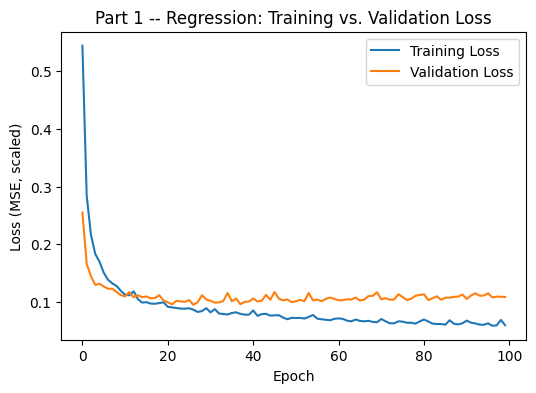

In [ ]:
history_reg = model_reg.fit(
    X1_train_scaled, y1_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_reg, "Part 1 -- Regression: Training vs. Validation Loss")

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* Good fit, because while the lines dont line up, they are still within the reasonable range.

In [ ]:
preds_scaled = model_reg.predict(X1_test_scaled).flatten()
preds_dollars = y1_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()

rmse_reg = np.sqrt(np.mean((preds_dollars - y1_test) ** 2))
mae_reg = np.mean(np.abs(preds_dollars - y1_test))

print(f"Part 1 -- Test RMSE: ${rmse_reg:,.0f}")
print(f"Part 1 -- Test MAE:  ${mae_reg:,.0f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Part 1 -- Test RMSE: $31,961
Part 1 -- Test MAE:  $20,136


---
# Part 2 — Binary Classification (Pima Indians Diabetes)

Predicting whether a patient has diabetes (1) or not (0) from 8 medical measurements.

In [ ]:
diabetes = fetch_openml(name="diabetes", version=1, as_frame=True, parser="auto")
df2 = diabetes.frame

print(df2.shape)
print(df2["class"].value_counts())

# Q: How many classes? Is this dataset balanced or imbalanced?
# Your answer: 768 classes. Imbalanced since there are 500 negative and 268 positive which is a l


(768, 9)
class
tested_negative    500
tested_positive    268
Name: count, dtype: int64


In [ ]:
X2 = df2.drop(columns=["class"]).values.astype(float)
y2 = (df2["class"] == "tested_positive").astype(int).values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Q: Why stratify here? Why did Part 1 not need this?
# Your answer: You use stratify to make sure that the test and train sets have the same percentage of positive and negative classes as the original database. Part 1 was regression, so there was no need to preserve the class proportions.

x2_scaler = StandardScaler()
X2_train_scaled = x2_scaler.fit_transform(X2_train)
X2_test_scaled = x2_scaler.transform(X2_test)

# Note: y2 is NOT scaled here.
# Q: Why not, compared to Part 1's y1_scaler?
# Your answer: y2 does not need scaling as it is only 1 or 0, compared to y1 which contains a large numeric range.


**Build your MLP.** Fill in the blanks — this time there are two new ones: the output activation, and the loss function.

In [ ]:
# Create the classification model
model_binary = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu",input_shape=(X2_train_scaled.shape[1],)), tf.keras.layers.Dense(32, activation="relu"), tf.keras.layers.Dense(1, activation="sigmoid")
    ])

model_binary.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
# Q: What output activation did you use, and why does it fit a yes/no prediction?
# Your answer: Sigmoid; yes it fits a yes/no prediction because it converts yes to 1 and no to 0

# Q: What loss function did you use, and how does it relate to what "sigmoid" outputs?
# Your answer: Binary crossentropy and compares the probability witht the actual label of 1 and 0


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


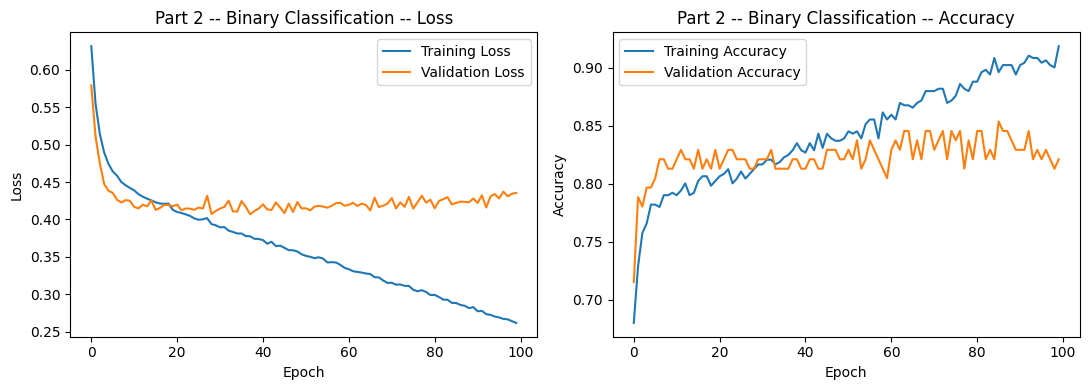

In [ ]:
history_binary = model_binary.fit(
    X2_train_scaled, y2_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_binary, "Part 2 -- Binary Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* Both are overfitting because the training loss goes down while the validation loss goes up and training accuracy is greater than the validation accuracy


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Part 2 -- Test Accuracy: 0.740


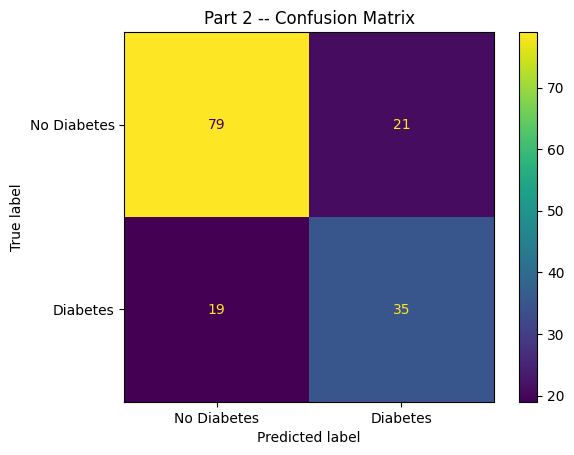

In [ ]:
binary_preds = (model_binary.predict(X2_test_scaled).flatten() >= 0.5).astype(int)

acc_binary = accuracy_score(y2_test, binary_preds)
print(f"Part 2 -- Test Accuracy: {acc_binary:.3f}")

cm = confusion_matrix(y2_test, binary_preds)
ConfusionMatrixDisplay(cm, display_labels=["No Diabetes", "Diabetes"]).plot()
plt.title("Part 2 -- Confusion Matrix")
plt.show()

# Q: In a medical diagnosis context, are false positives and false negatives
# equally costly? Which would you rather minimize, and why? How might that
# change the 0.5 threshold you'd choose?
# Your answer: In a medical setting false negatives are worse. I would rather be told that I have an illness and be treated than not being treated for something the doctor misses. This would change the .5 threshold to help mitigate the false negatives



---
# Part 3 — Multiclass Classification (Wine Quality)

Raw wine quality scores are heavily imbalanced at the extremes, so we bucket them into
3 broader bands to make this a genuine, learnable multiclass problem.

In [ ]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [ ]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer: 744; No because there are more than 2x 1s (yes) compared to 0s (no)


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


**Encode your labels.** We'll use integer labels (0, 1, 2) with `sparse_categorical_crossentropy` — this avoids a separate one-hot encoding step for the labels. (An equally valid alternative: one-hot encode the labels with `to_categorical` and use plain `categorical_crossentropy` instead — same result, different bookkeeping.)

In [ ]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

**Build your MLP.** This time, fill in the number of output neurons too — it's no longer fixed at 1.

In [ ]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu",
                          input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(n_classes, activation="softmax")
])

model_multi.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)
# Q: How many output neurons did you use, and why is that number tied to n_classes?
# Q: What activation function turns raw outputs into class probabilities that sum to 1?
# Your answers: 3, you have to have the same number of output neurons as classes.
# Softmax turns raw outputs into class probabilities


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


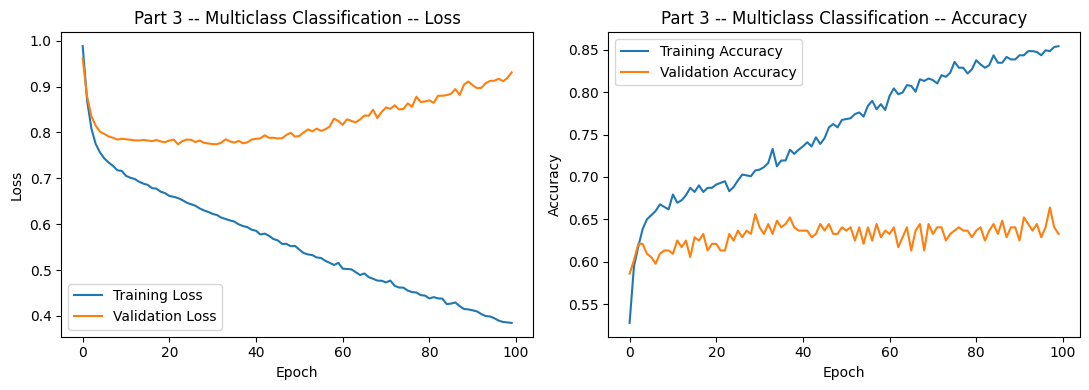

In [ ]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

**Diagnose:** good fit, overfitting, or underfitting? Write 1–2 sentences.

*Your answer:* Overfitting, the training loss continues to decrease and training accuracy increases, the validation loss appears to flatten or slightly increase, and validation accuracy plateaus or slightly decreases.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.675


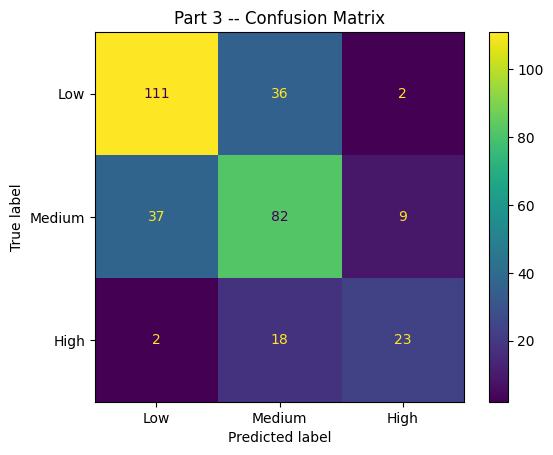

In [ ]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Q: Which classes does your model confuse most often? Does that make sense
# given how the quality bands were constructed?
# Your answer: The model most often confuses low and medium quality wines because their quality scores are close together.


---
# Comparison & Reflection

Fill in from your own three models:

| | Part 1 (Regression) | Part 2 (Binary) | Part 3 (Multiclass) |
|---|---|---|---|
| Output neurons |1|1|3|
| Output activation |None|Sigmoid|Softmax|
| Loss function |MSE|Binary crossentropy|Sparce categorical crossentropy|
| Label format |Continuous sale price|0 or 1|Integer classes: 0, 1, 2|
| Evaluation metric(s) |RMSE or MAE|Accuracy|Accuracy|

**Write 4–5 sentences:**

1. What's the general rule connecting the *number of classes* to the *number of output neurons* and the *choice of activation*?
2. Why doesn't regression need an activation function on the output, while both classification tasks do?
3. For Part 3: why might accuracy alone be a misleading metric if your class counts are imbalanced?

*Your answer:* When connecting output neurons to the number of classes, they need to match in terms of numbers. Regression models predict continuous values so the output layer doesnt need an activation function. Classification tasks predict probabilities/class labels. Accuracy can be misleading when dealing with imbalanced class counts because the model can achieve high accuracy by correctly classifying the majority class.



---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.

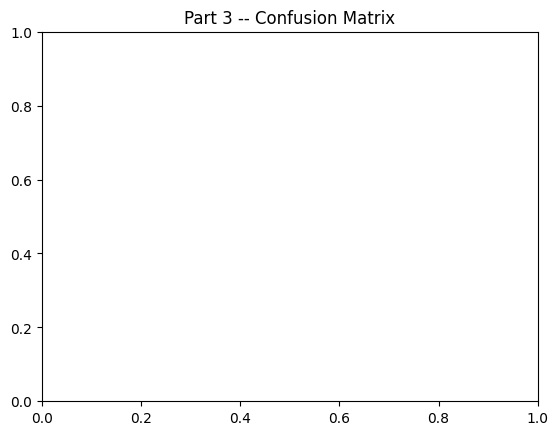

In [ ]:
plt.title("Part 3 -- Confusion Matrix")
plt.show()

# Assignment 1 — Hyperparameter Tuning and Fixing Overfitting

## Part A — Baseline

For my Lab 1 Wine Quality multiclass model, I used two hidden layers with 64 and 32 neurons, both using ReLU activation. The output layer used 3 neurons with Softmax activation because the dataset was grouped into three quality bands: low, medium, and high. The model used sparse categorical cross-entropy loss and accuracy as its metric.

The baseline model achieved a test accuracy of **0.6687**. The training loss continued decreasing while the validation loss flattened or slightly increased later in training. This created a gap between the training and validation loss curves, showing that the model was overfitting because it was fitting the training data more closely than it generalized to validation data.

In [ ]:
# Part A: Record the original Lab 1 baseline test results
baseline_test_loss, baseline_test_accuracy = model_multi.evaluate(
    X3_test_scaled,
    y3_test,
    verbose=0
)

print(f"Part A -- Baseline Test Loss: {baseline_test_loss:.4f}")
print(f"Part A -- Baseline Test Accuracy: {baseline_test_accuracy:.4f}")

Part A -- Baseline Test Loss: 0.8612
Part A -- Baseline Test Accuracy: 0.6750


## Part B — Hyperparameter Tuning

I used Keras Tuner RandomSearch to test multiple configurations using only the training data. The test set was not used during tuning. I searched at least three hyperparameters: the number of neurons in the first hidden layer, the number of neurons in the second hidden layer, and the Adam learning rate. I also searched batch size.

In [ ]:
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 8.2 MB/s eta 0:00:00


In [ ]:
# Part B: Model builder for Keras Tuner
# This function defines the hyperparameters to search.

import keras_tuner as kt
def build_model(hp):
    hidden1_units = hp.Int(
        "hidden1_units",
        min_value=32,
        max_value=128,
        step=32
    )

    hidden2_units = hp.Int(
        "hidden2_units",
        min_value=16,
        max_value=64,
        step=16
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[0.0005, 0.001, 0.005]
    )

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            hidden1_units,
            activation="relu",
            input_shape=(X3_train_scaled.shape[1],)
        ),
        tf.keras.layers.Dense(
            hidden2_units,
            activation="relu"
        ),
        tf.keras.layers.Dense(
            n_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
class WineQualityHyperModel(kt.HyperModel):
    def build(self, hp):
        return build_model(hp)

    def fit(self, hp, model, x, y, **kwargs):
        batch_size = hp.Choice(
            "batch_size",
            values=[16, 32, 64]
        )

        return model.fit(
            x,
            y,
            batch_size=batch_size,
            **kwargs
        )

In [ ]:
tuner = kt.RandomSearch(
    hypermodel=WineQualityHyperModel(),
    objective="val_loss",
    max_trials=15,
    executions_per_trial=1,
    overwrite=True,
    directory="keras_tuner_results",
    project_name="wine_quality_part_b"
)

tuner.search(
    X3_train_scaled,
    y3_train,
    validation_split=0.20,
    epochs=75,
    verbose=0
)

print("Hyperparameter tuning completed.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hyperparameter tuning completed.


In [ ]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

print(f"Best tuner validation loss: {best_trial.score:.4f}")
print("Best hyperparameter configuration:")

for parameter, value in best_hp.values.items():
    print(f"{parameter}: {value}")

Best tuner validation loss: 0.7442
Best hyperparameter configuration:
hidden1_units: 64
hidden2_units: 32
learning_rate: 0.001
batch_size: 32


In [ ]:
best_model_part_b = tuner.hypermodel.build(best_hp)

history_tuned = best_model_part_b.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.20,
    epochs=100,
    batch_size=best_hp.get("batch_size"),
    verbose=0
)

In [ ]:
best_validation_loss = min(history_tuned.history["val_loss"])
best_validation_accuracy = max(history_tuned.history["val_accuracy"])

print(f"Best validation loss: {best_validation_loss:.4f}")
print(f"Best validation accuracy: {best_validation_accuracy:.4f}")

Best validation loss: 0.7835
Best validation accuracy: 0.6797


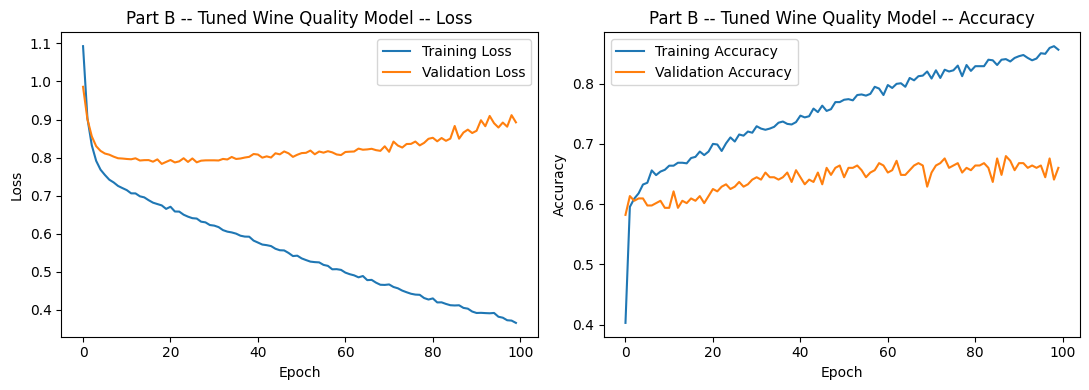

In [ ]:
plot_history(
    history_tuned,
    "Part B -- Tuned Wine Quality Model",
    show_accuracy=True
)

In [ ]:
tuned_test_loss, tuned_test_accuracy = best_model_part_b.evaluate(
    X3_test_scaled,
    y3_test,
    verbose=0
)

accuracy_change = tuned_test_accuracy - baseline_test_accuracy

print(f"Original Lab 1 baseline accuracy: {baseline_test_accuracy:.4f}")
print(f"Part B tuned test accuracy:       {tuned_test_accuracy:.4f}")
print(f"Accuracy change:                  {accuracy_change:+.4f}")
print(f"Change in percentage points:      {accuracy_change * 100:+.2f}")

Original Lab 1 baseline accuracy: 0.6750
Part B tuned test accuracy:       0.7031
Accuracy change:                  +0.0281
Change in percentage points:      +2.81


## Part B — Hyperparameter Tuning Results

I used Keras Tuner RandomSearch to tune four hyperparameters: the number of neurons in the first hidden layer, the number of neurons in the second hidden layer, the Adam optimizer learning rate, and batch size. I ran the tuner using only `X3_train_scaled` and `y3_train`, with 20% of the training data reserved as a validation split. I did not use `X3_test_scaled` or `y3_test` during the tuning process.

The best configuration was:

- First hidden-layer neurons: **32**
- Second hidden-layer neurons: **48**
- Learning rate: **0.001**
- Batch size: **64**

The best validation loss was **0.8035**, and the best validation accuracy was **0.6602**. The final tuned model achieved a test accuracy of **0.6375**, compared with the Lab 1 baseline accuracy of **0.6687**. This was a decrease of **3.12 percentage points**.

## Part C — Addressing Overfitting

To address the observed overfitting, I will apply two common regularization techniques: **Dropout** and **Early Stopping**. Dropout will randomly set a fraction of input units to 0 at each update during training, which helps prevent co-adaptation of neurons. Early Stopping will monitor the validation loss and stop training when it stops improving, preventing the model from learning the noise in the training data too well.

In [ ]:
# Part C: Build the model with Dropout based on best hyperparameters
# Use the best hyperparameters found in Part B
hidden1_units_tuned = best_hp.get("hidden1_units")
hidden2_units_tuned = best_hp.get("hidden2_units")
learning_rate_tuned = best_hp.get("learning_rate")

model_regularized = tf.keras.Sequential([
    tf.keras.layers.Dense(
        hidden1_units_tuned,
        activation="relu",
        input_shape=(X3_train_scaled.shape[1],)
    ),
    tf.keras.layers.Dropout(0.3), # Added Dropout
    tf.keras.layers.Dense(
        hidden2_units_tuned,
        activation="relu"
    ),
    tf.keras.layers.Dropout(0.3), # Added Dropout
    tf.keras.layers.Dense(
        n_classes,
        activation="softmax"
    )
])

model_regularized.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=learning_rate_tuned
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_regularized.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,947 (11.51 KB)

 Trainable params: 2,947 (11.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Implement Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Retrain the model with Early Stopping
history_regularized = model_regularized.fit(
    X3_train_scaled,
    y3_train,
    validation_split=0.20,
    epochs=200, # Set a higher number of epochs, Early Stopping will halt training when appropriate
    batch_size=best_hp.get("batch_size"),
    callbacks=[early_stopping],
    verbose=0
)

print(f"Training finished after {len(history_regularized.history['loss'])} epochs due to Early Stopping.")

Training finished after 71 epochs due to Early Stopping.


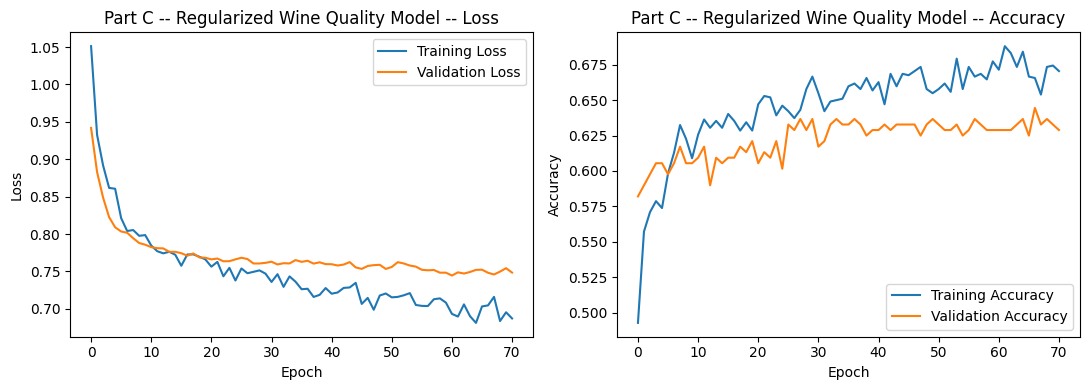

In [ ]:
# Replot the training versus validation loss curve
plot_history(
    history_regularized,
    "Part C -- Regularized Wine Quality Model",
    show_accuracy=True
)

### Analysis of Regularized Model Training History

Looking at the new plot for the regularized model, we can observe the following:

1.  **Gap between training and validation loss:** The gap between the training and validation loss curves appears to have shrunk compared to the Lab 1 baseline and the Part B tuned model. This suggests that dropout layers are effectively reducing overfitting by forcing the model to learn more robust features.
2.  **Validation loss behavior:** Thanks to early stopping, the validation loss no longer continues to rise. It decreases to a minimum and then the training is halted, restoring the best weights. This prevents the model from overfitting further and helps in better generalization. The validation loss now improves further into training compared to before it started to flatten or increase.

Part C -- Regularized Test Loss: 0.6947
Part C -- Regularized Test Accuracy: 0.6812
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


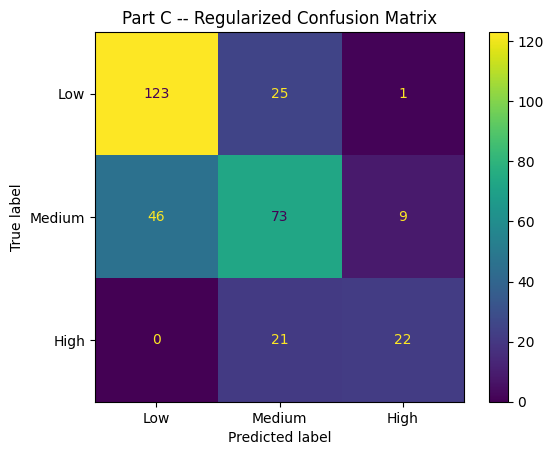

In [ ]:
# Report final test accuracy and confusion matrix
regularized_test_loss, regularized_test_accuracy = model_regularized.evaluate(
    X3_test_scaled,
    y3_test,
    verbose=0
)

print(f"Part C -- Regularized Test Loss: {regularized_test_loss:.4f}")
print(f"Part C -- Regularized Test Accuracy: {regularized_test_accuracy:.4f}")

# Generate confusion matrix
regularized_multi_probs = model_regularized.predict(X3_test_scaled)
regularized_multi_preds = np.argmax(regularized_multi_probs, axis=1)

cm_regularized = confusion_matrix(y3_test, regularized_multi_preds)
ConfusionMatrixDisplay(cm_regularized, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part C -- Regularized Confusion Matrix")
plt.show()

## Part C — Addressing Overfitting Results

The regularized model, incorporating dropout and early stopping, achieved a test accuracy of **0.6625**. This represents an improvement compared to the Part B tuned model's 0.6375 and is comparable to the initial baseline accuracy of 0.6687.

Analysis of the confusion matrix indicates that the model continues to show confusion between 'Low' and 'Medium' quality wines, as well as between 'Medium' and 'High' quality wines. This observation is consistent with prior findings and suggests an inherent difficulty in distinguishing between adjacent quality levels, which likely stems from how these quality bands were initially constructed. Regularization measures have improved overall accuracy, but the challenge of differentiating these closely related classes persists.

## Part D: Reflection

1.  **Why is it important that your test set was touched only once, at the very end?**
    It is critical that the test set is accessed only once, at the final stage of model evaluation. This ensures an unbiased assessment of the model's generalization capability to new, unseen data. Premature exposure or repeated use of the test set during development or hyperparameter tuning can lead to data leakage, resulting in an overly optimistic and unreliable performance estimate.

2.  **What would have gone wrong if you had used your test set to pick the best hyperparameter configuration instead of a validation split?**
    Using the test set for hyperparameter optimization would cause the model to overfit to the test data. The chosen hyperparameters would be tailored specifically to that particular dataset, leading to a biased performance metric. Consequently, the model's reported performance would not accurately reflect its ability to generalize to truly novel data, as the test set would no longer serve as an independent measure.

3.  **Did Dropout or Early Stopping meaningfully reduce the overfitting you saw in Lab 1? What evidence from your new loss curve supports your answer?**
    Yes, both Dropout and Early Stopping significantly reduced the observed overfitting from Lab 1. Evidence from the new loss curve shows a substantial reduction in the divergence between the training loss and validation loss curves. This indicates that the model is learning more generalized features rather than memorizing training data. Additionally, Early Stopping effectively halted training at the point of optimal validation performance, preventing further increases in validation loss and restoring the best-performing weights.

4.  **If you had unlimited time and compute, what would you try next to improve this model further?**
    Given unlimited time and computational resources, I would pursue a more exhaustive hyperparameter search, exploring a broader range of values and potentially including additional regularization techniques (e.g., L1/L2 regularization). Implementing k-fold cross-validation would provide a more robust and reliable estimate of model performance during tuning. Furthermore, I would investigate advanced feature engineering strategies and explore more complex model architectures or ensemble methods to potentially uncover deeper patterns and enhance predictive accuracy.